# 07 — Derivative and noise

**The derivative does not care how big the noise is, only how fast.**

In notebook 05 the derivative was free. It took the PI loop's 44% overshoot down to 3% on the
same car, the same step and the same gain, and it cost nothing anywhere else in the run —
exactly zero at both ends, by construction. This notebook is the bill.

Every measurement this lecture has used so far has been perfect. The controller was handed the
car's speed, to machine precision, at every instant. Real loops are not given that; they are
given a sensor reading, which is the speed plus whatever else the sensor and the wiring picked
up on the way. That difference is invisible on the speed trace and it is ruinous on the
actuator, because differentiating a signal multiplies every component of it by that component's
own frequency — and noise is all frequency.

By the end of this notebook `Nd` will have stopped being a number that every notebook since 05
has been quietly leaving at 10.

## Setup

Same bootstrap as every notebook in this set, and two conventions carried over from notebook 05
because this notebook would say nothing without them.

**The torque ceiling stays lifted, and so does the floor.** `T_max`, `y_max` and `y_min` are all
set out of the way, so the plots below show what the controller *asks for* rather than what the
limiter lets past. A command clipped at the engine's 150 N.m would hide most of the damage
behind a flat line — and it is the size of the ask, not the size of what survives, that this
notebook is about.

**The derivative acts on the measurement, not on the error** — `wd = 0`. Differentiating a
setpoint step commands a spike four orders of magnitude beyond anything the engine could do,
which says everything about differentiating a discontinuity and nothing about derivative action.
`NoisyCruiseLoop` seeds the derivative filter's state from the initial measurement for the same
reason notebook 05 did it by hand.

In [1]:
isdefined(Main, :Lecture01Support) || include("support.jl")

# Bound by hand rather than with `using`. If this kernel ever ran an earlier `include` of
# support.jl there are two copies of the module, every name both export is ambiguous, and no
# amount of re-running `using` resolves it. An explicit binding does, so this cell repairs a
# kernel in that state instead of needing it restarted. Editing support.jl still needs a
# restart, because the guard above deliberately will not load a second copy.
for n in names(Lecture01Support)
    n === :Lecture01Support && continue
    Core.eval(Main, :($n = Lecture01Support.$n))
end

In [2]:
setup()

Main.VehicleSystemsComponents

## 1. Every sensor is noisy

Noise is not a defect in a sensor, it is a property of one. Thermal agitation in the resistors,
shot noise in the semiconductor junctions, flicker noise at low frequency, and — in a car,
dominating all of them — everything else in the vehicle coupling into the wiring: the
alternator, the injectors, the ignition, the ABS ring's own tooth-passing frequency. A
speedometer is no exception. The number on the dashboard is the speed plus a small, fast,
never-repeating wobble, and the wobble is why the dashboard needle is damped.

The loop below is notebook 05's cruise controller with a speedometer that behaves like a real
one.

### The models this runs

`NoisyCruiseLoop` is `CruiseLoop` with one block inserted: `MeasurementNoise`, sitting between
the plant's speed output and the controller's measurement input. Nothing else changes — same
car, same `LimPID`, same gains. The true speed stays readable as `loop.plant.v_kmh`, and
`loop.noise.y` is the corrupted reading the controller actually sees. Every notebook before this
one has been reading the first and pretending it was the second.

In [3]:
show_dyad("NoisyCruiseLoop")

NoisyCruiseLoop — dyad/Lecture1/NoisyCruiseLoop.dyad line 1 
 """
Cruise-control loop with deterministic noise in the speed-measurement path.

The plant speed remains available as `plant.v_kmh`, while `noise.y` is the measurement seen by
the controller. The loop signals and noise amplitude are in km/h.
"""
component NoisyCruiseLoop
 "Vehicle-speed setpoint in km/h"
 setpoint = RealInput()
 "Road gradient, tan(alpha)"
 grade = RealInput()
 "Powertrain transport delay"
 structural parameter theta_e::Time = 0.3
 "Whether to include integral action"
 structural parameter with_I::Boolean = true
 "Whether to include derivative action"
 structural parameter with_D::Boolean = true
 "Controller gain in N.m per km/h"
 parameter k::Real = 56.0
 parameter Ti::Time = 10.0
 parameter Td::Time = 0.1
 parameter Nd::Real = 10.0
 parameter Ni::Real = 0.9
 parameter T_max::Torque = 150.0
 parameter y_max::Real = T_max
 parameter y_min::Real = 0.0
 parameter wp::Real = 1.0
 parameter wd::Real = 1.0
 parameter m::Dyad.Mass = 1400.0
 parameter CdA::Area = 0.63
 "Amplitude of each measurement-noise sinusoid in km/h"
 parameter amplitude::Real = 0.2
 "Initial measured speed in km/h, the settled cruise the loop starts from"
 parameter m0::Real = 90.0
 parameter xi0::Real = 0.0
 "Initial derivative-filter state, seeded from the initial measurement"
 parameter xd0::Real = (wd - 1) * m0
 plant = VehicleSystemsComponents.Vehicle.CarPlant(theta_e = theta_e, T_max = T_max, m = m, CdA = CdA)
 controller = BlockComponents.Continuous.LimPID(
 with_I = with_I,
 with_D = with_D,
 k = k,
 Ti = Ti,
 Td = Td,
 Nd = Nd,
 Ni = Ni,
 y_max = y_max,
 y_min = y_min,
 wp = wp,
 wd = wd,
 xi0 = xi0,
 xd0 = xd0)
 noise = VehicleSystemsComponents.Lecture1.MeasurementNoise(amplitude = amplitude)
 "No separate feedforward path in this feedback loop"
 zero_ff = BlockComponents.Sources.Constant(k = 0.0)
relations
 connect(setpoint, controller.u_s)
 connect(plant.v_kmh, noise.u)
 connect(noise.y, controller.u_m)
 connect(zero_ff.y, controller.u_ff)
 connect(controller.y, plant.tau_cmd)
 connect(grade, plant.grade)
end

Two connections carry the whole difference: `plant.v_kmh` goes into `noise.u` instead of
straight into the controller, and `noise.y` comes out the other side into `controller.u_m`.

The noise block itself is worth reading, because its equation is the subject of this notebook
rather than its plumbing.

In [4]:
show_dyad("MeasurementNoise")

MeasurementNoise — dyad/Lecture1/MeasurementNoise.dyad line 1 
 """
Additive measurement noise: a deterministic sum of sines.

Adds broadband noise to a signal (the km/h speed measurement in notebook 07) so the notebook can
show what the controller's derivative term does with a noisy input. The noise is a fixed sum of
sinusoids, never a random-number generator: the notebooks ship with executed outputs, and a plot
that changes between runs is worthless in a lecture.

Every component has the same amplitude and the frequencies are spread over about a decade and a
half. That is deliberate. The filtered derivative's gain rises with frequency, so with equal
amplitudes the high-frequency components dominate the derivative output — the amplification shows
up as a function of frequency rather than of amplitude, which is the point notebook 07 makes.
"""
component MeasurementNoise
 extends BlockComponents.Interfaces.SISO
 "Amplitude of each sinusoid; equal across components so amplification tracks frequency, not amplitude"
 parameter amplitude::Real = 0.2
 "Component frequencies in Hz, spread over ~1.5 decades"
 parameter f1::Frequency = 0.5
 parameter f2::Frequency = 1.0
 parameter f3::Frequency = 2.0
 parameter f4::Frequency = 4.0
 parameter f5::Frequency = 8.0
 parameter f6::Frequency = 16.0
 # Fixed, non-zero phase offsets so the components do not all peak at t = 0 and masquerade as a
 # single spike. Any fixed set works; these keep the sum reproducible run to run.
 parameter p1::Real = 0.0
 parameter p2::Real = 0.7
 parameter p3::Real = 1.5
 parameter p4::Real = 2.2
 parameter p5::Real = 3.0
 parameter p6::Real = 3.9
relations
 y = u + amplitude * (
 sin(2 * pi * f1 * time + p1) +
 sin(2 * pi * f2 * time + p2) +
 sin(2 * pi * f3 * time + p3) +
 sin(2 * pi * f4 * time + p4) +
 sin(2 * pi * f5 * time + p5) +
 sin(2 * pi * f6 * time + p6))
end

Six sinusoids, **equal amplitude**, spread over about a decade and a half — 0.5 Hz to 16 Hz.

The equal amplitudes are the experiment. If the components were tapered, anything the derivative
did with them could be blamed on where the energy happened to sit. Flat across the band, there is
only one variable left, and whatever the derivative amplifies it is amplifying *because of its
frequency*. That is the notebook's whole claim, built into the noise source so it cannot be
argued with afterwards.

The fixed phases are the other half of the same discipline: this is a deterministic signal, not a
random draw, so the plots below are the plots you will get when you re-run the cell.

  noise excursion          -0.791 to 0.9 km/h
  true speed, 20 to 30 s   109.739 to 110.496 km/h
  overshoot on the step    5.22 %


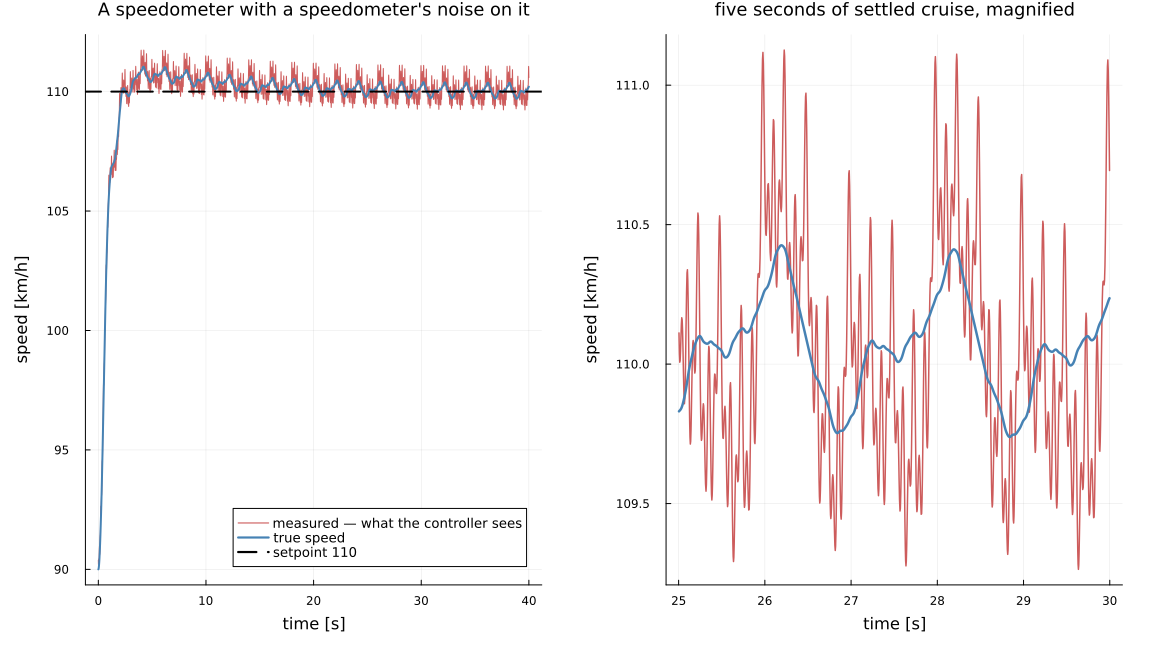

In [5]:
Scenarios = VehicleSystemsComponents.Lecture1

TRUE_SPEED = "loop.plant.v_kmh"       # what the car is doing
MEASURED = "loop.noise.y"             # what the controller is told
COMMAND = "loop.controller.y"         # what the controller asks the engine for

SETPOINT = 110.0      # km/h
GAIN = 56.0           # N.m per km/h, notebook 05's gain
T_I = 10.0            # s
T_D = 0.5             # s — the value notebook 05's sweep landed on
UNLIMITED = 1.0e6     # N.m, both ways: the plots show the ask, not the clipped ask
STOP = 40.0           # s

# The settled-cruise window. The step is long over by 20 s and the integrator has stopped
# moving, so what is left in it is the noise and nothing else.
CRUISE = (20.0, 30.0)

# Every plot below is handed the window it is read over, rather than the whole run with the
# rest hidden behind `xlims`. Hidden points stay in an exported SVG, and at these cutoffs a
# run is tens of thousands of solver steps — enough to make the deck crawl on a projector.
function segment(sol, path, span)
    tt, yy = signal(sol, path)
    keep = first(span) .<= tt .<= last(span)
    return (tt[keep], yy[keep])
end

# Nd = 10 is the LimPID default and what every notebook since 05 has silently been running.
noisy = Scenarios.NoisyCruiseTransient(
    k = GAIN, Ti = T_I, Td = T_D, Nd = 10.0, wd = 0.0,
    T_max = UNLIMITED, y_max = UNLIMITED, y_min = -UNLIMITED, stop = STOP)

t, v_true = signal(noisy, TRUE_SPEED)
_, v_meas = signal(noisy, MEASURED)
wobble = v_meas .- v_true

println("  noise excursion          ", round(minimum(wobble), digits = 3), " to ",
        round(maximum(wobble), digits = 3), " km/h")
println("  true speed, 20 to 30 s   ",
        round(minimum(v_true[20 .<= t .<= 30]), digits = 3), " to ",
        round(maximum(v_true[20 .<= t .<= 30]), digits = 3), " km/h")
println("  overshoot on the step    ", round(overshoot(noisy, SETPOINT; sig = TRUE_SPEED), digits = 2), " %")

whole = plot(t, v_meas; lw = 1, color = :indianred, label = "measured — what the controller sees",
             xlabel = "time [s]", ylabel = "speed [km/h]", legend = :bottomright,
             title = "A speedometer with a speedometer's noise on it")
plot!(whole, t, v_true; lw = 2, color = :steelblue, label = "true speed")
hline!(whole, [SETPOINT]; ls = :dash, lw = 2, color = :black, label = "setpoint 110")

cruise = plot(segment(noisy, MEASURED, (25.0, 30.0))...; lw = 1.5, color = :indianred,
              label = "", xlabel = "time [s]", ylabel = "speed [km/h]", legend = false,
              title = "five seconds of settled cruise, magnified")
plot!(cruise, segment(noisy, TRUE_SPEED, (25.0, 30.0))...; lw = 2.5, color = :steelblue, label = "")

measurement = plot(whole, cruise; layout = (1, 2), size = (1150, 650))
save_figure(measurement, "07-true-vs-measured")
measurement

Look at that and decide whether it is good enough.

Most people say yes, and they are right to. The reading wanders 0.79 km/h below the truth and
0.90 above it — well under the tolerance of the speedometer in any car you have driven, far below
anything a driver could see on a needle, and the loop still arrives at 110 km/h and holds it. It
overshoots the step by 5.2% where notebook 05's noiseless version managed 3.1%, which is a real
cost and a small one. On the left-hand axes the noise is a fuzz around a curve that does what it
is supposed to; you have to magnify five seconds of settled cruise before there is a waveform to
look at.

That is the trap. Everything in this plot is the *controlled variable* — the thing we set out to
control, behaving. The next two sections are about a signal this plot does not contain.

## 2. Why small noise is not safe

Differentiate a sine and you get a cosine of the same frequency — and a different amplitude:

$$
\frac{d}{dt}\bigl[A\sin(\omega t)\bigr] \;=\; A\,\omega\cos(\omega t)
$$

The amplitude of the derivative is $A\omega$. Multiply the frequency by ten and the derivative is
ten times bigger, with $A$ untouched. A derivative does not report how big a signal is; it
reports how *steep* it is, and steepness is size times frequency.

The plot below is that sentence, twice: two sines you could not tell apart by amplitude, and the
derivatives you get from them.

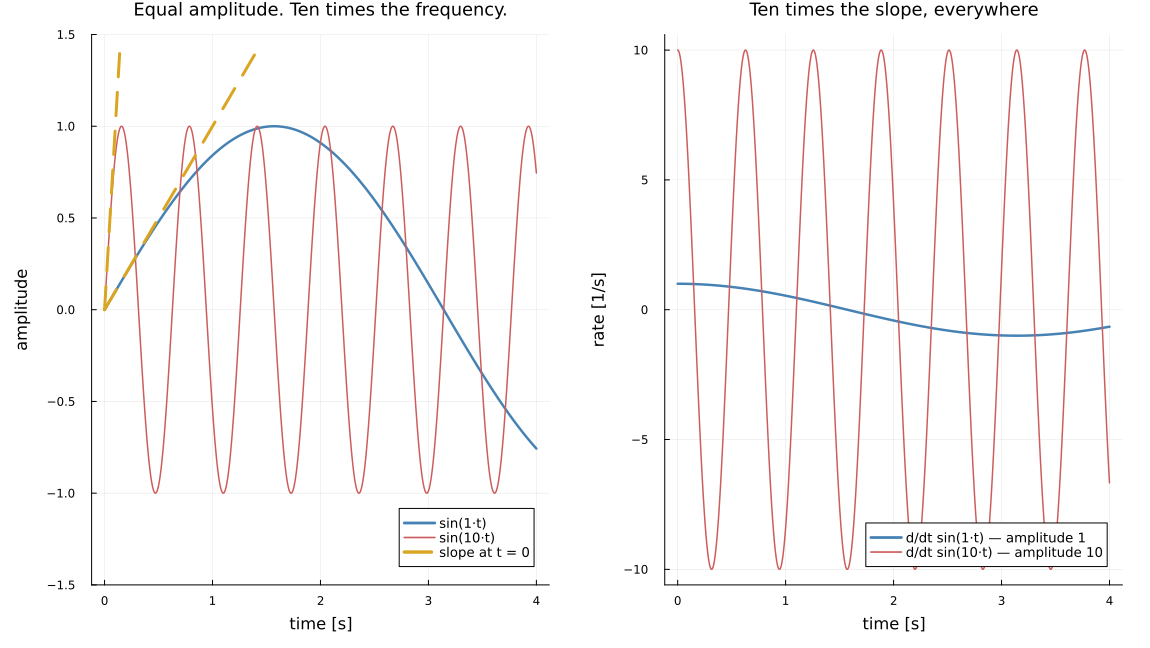

In [6]:
A = 1.0                     # equal amplitude, exactly as in the noise block
W_SLOW, W_FAST = 1.0, 10.0  # rad/s, a decade apart
ts = range(0, 4; length = 2000)

# Drawn from t = 0, where a sine is steepest and its tangent has slope A*w exactly.
tangent(w, span) = (span, w .* span)
reach(w) = range(0, 1.4 / w; length = 2)

sines = plot(ts, A .* sin.(W_SLOW .* ts); lw = 2.5, color = :steelblue,
             label = "sin(1·t)", xlabel = "time [s]", ylabel = "amplitude",
             ylims = (-1.5, 1.5), legend = :bottomright,
             title = "Equal amplitude. Ten times the frequency.")
plot!(sines, ts, A .* sin.(W_FAST .* ts); lw = 1.5, color = :indianred, label = "sin(10·t)")
plot!(sines, tangent(W_SLOW, reach(W_SLOW))...; lw = 3, color = :goldenrod, ls = :dash,
      label = "slope at t = 0")
plot!(sines, tangent(W_FAST, reach(W_FAST))...; lw = 3, color = :goldenrod, ls = :dash, label = "")

derivs = plot(ts, A * W_SLOW .* cos.(W_SLOW .* ts); lw = 2.5, color = :steelblue,
              label = "d/dt sin(1·t) — amplitude 1", xlabel = "time [s]",
              ylabel = "rate [1/s]", legend = :bottomright,
              title = "Ten times the slope, everywhere")
plot!(derivs, ts, A * W_FAST .* cos.(W_FAST .* ts); lw = 1.5, color = :indianred,
      label = "d/dt sin(10·t) — amplitude 10")

two_sines = plot(sines, derivs; layout = (1, 2), size = (1150, 650))
save_figure(two_sines, "07-two-sines")
two_sines

Now put this car's numbers through it.

Each of the six noise components carries the same 0.2 km/h. The derivative path of a PID
contributes `k·Td·de/dt` to the command, so an unfiltered derivative turns a component of
amplitude `A` at frequency `ω` into `k·Td·A·ω` newton-metres of torque demand. Nothing in that
expression knows what the noise means; it is arithmetic.

In [7]:
AMPLITUDE = 0.2              # km/h per component, the MeasurementNoise default
FREQUENCIES = [0.5, 1.0, 2.0, 4.0, 8.0, 16.0]   # Hz

println("   f [Hz]   ω [rad/s]   dA/dt [km/h per s]   k·Td·A·ω [N.m]")
for f in FREQUENCIES
    w = 2π * f
    println("  ", rpad(f, 8), " ", rpad(round(w, digits = 2), 11),
            " ", rpad(round(AMPLITUDE * w, digits = 3), 20),
            " ", round(GAIN * T_D * AMPLITUDE * w, digits = 1))
end
println("\n  all six, if they line up:  ",
        round(sum(GAIN * T_D * AMPLITUDE * 2π * f for f in FREQUENCIES), digits = 1), " N.m")
println("  torque the car needs to hold 110 km/h:  40.1 N.m")

   f [Hz]   ω [rad/s]   dA/dt [km/h per s]   k·Td·A·ω [N.m]
  0.5      3.14        0.628                17.6
  1.0      6.28        1.257                35.2
  2.0      12.57       2.513                70.4
  4.0      25.13       5.027                140.7
  8.0      50.27       10.053               281.5
  16.0     100.53      20.106               563.0

  all six, if they line up:  1108.4 N.m
  torque the car needs to hold 110 km/h:  40.1 N.m


The bottom component is worth about 18 N.m — background hum next to a 40 N.m holding torque. The
top component, the same 0.2 km/h thirty-two times faster, is worth 563 N.m, which is nearly four
times what the engine can produce. The six of them together can ask for over a kilonewton-metre
when their phases happen to align.

None of that is visible in section 1's plot, because none of it is in the speed. It is in the
slope of the speed, and the only thing in the loop that looks at slope is the derivative term.

## 3. A near-pure derivative

`LimPID` does not implement a bare derivative. It implements a filtered one:

$$
T_d s \quad\longrightarrow\quad \frac{T_d\,s}{1 + \dfrac{T_d}{N_d}s}
$$

which is a derivative in series with a first-order low-pass whose cutoff is at `Nd/Td` rad/s. At
frequencies well below the cutoff the two are the same thing. Above it, the bare derivative keeps
growing with frequency and the filtered one flattens off at a gain of `k·Nd`.

`Nd` is therefore the knob that decides how much of a real derivative this is. Push it up and the
cutoff goes with it; push it far enough and there is effectively no filter left. The run below
uses `Nd = 100` — a cutoff of 200 rad/s, or about 32 Hz, which is above the top of the noise
band. Everything the speedometer invents gets through, differentiated.

  Nd = 10  (section 1)   command -413.0    to 333.27    N.m   range 746.27      true speed 109.74 to 110.5 km/h
  Nd = 100 (near-pure)   command -836.6    to 924.02    N.m   range 1760.61     true speed 109.85 to 110.6 km/h


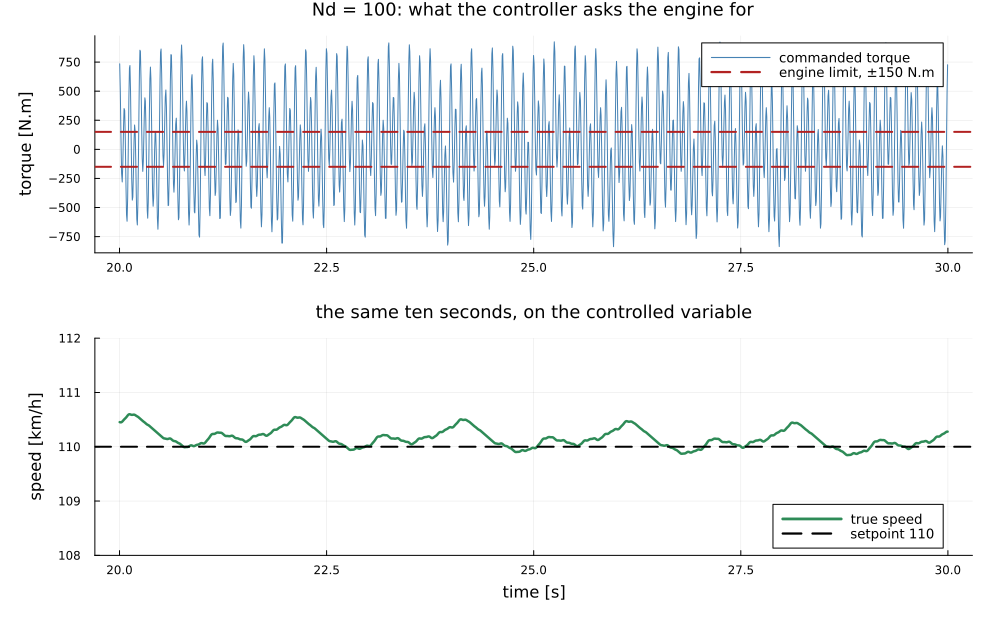

In [8]:
NEAR_PURE = 100.0     # cutoff Nd/Td = 200 rad/s, above the noise band's 16 Hz top

near_pure = rerun(noisy, "Nd" => NEAR_PURE)

for (label, sol) in (("Nd = 10  (section 1)", noisy), ("Nd = 100 (near-pure)", near_pure))
    u = last(segment(sol, COMMAND, CRUISE))
    v = last(segment(sol, TRUE_SPEED, CRUISE))
    println("  ", label,
            "   command ", rpad(round(minimum(u), digits = 2), 9), " to ",
            rpad(round(maximum(u), digits = 2), 9), " N.m",
            "   range ", rpad(round(maximum(u) - minimum(u), digits = 2), 9),
            "   true speed ", round(minimum(v), digits = 2), " to ", round(maximum(v), digits = 2), " km/h")
end

torque = plot(segment(near_pure, COMMAND, CRUISE)...; lw = 1, color = :steelblue,
              label = "commanded torque", xlabel = "", ylabel = "torque [N.m]",
              legend = :topright, title = "Nd = 100: what the controller asks the engine for")
hline!(torque, [CAR.T_max, -CAR.T_max]; ls = :dash, lw = 2, color = :firebrick,
       label = "engine limit, ±150 N.m")

speed = plot(segment(near_pure, TRUE_SPEED, CRUISE)...; lw = 2.5, color = :seagreen,
             label = "true speed", xlabel = "time [s]", ylabel = "speed [km/h]",
             ylims = (108, 112), legend = :bottomright,
             title = "the same ten seconds, on the controlled variable")
hline!(speed, [SETPOINT]; ls = :dash, lw = 2, color = :black, label = "setpoint 110")

chattering = plot(torque, speed; layout = (2, 1), size = (1000, 620))
save_figure(chattering, "07-chattering-command")
chattering

Two plots, ten seconds, one car, and they disagree completely about whether this loop works.

The lower one is the loop doing its job: 110 km/h, a wobble of a few tenths, nothing a passenger
could feel. If this were the only trace on the projector — and on most projectors it would be —
the controller would be signed off.

The upper one is the same ten seconds at the engine's input. The command swings across about
1760 N.m, twelve times the 150 N.m the engine can deliver and forty times the 40 N.m the car
actually needs to hold this speed — several times a second, for as long as the car is moving. The engine limit is on the
plot twice, above and below, and both lines are lost in the middle of the band.

It is worth being concrete about what that command *is*. It is a fuelling demand. It asks for
full torque and then for hard engine braking, alternating at up to sixteen times a second, on a
car travelling at a perfectly steady 110 km/h on a flat road. Nothing breaks today. Something
wears out early, or runs hot, or simply makes the car horrible to sit in — and none of it shows
up on the variable being controlled.

**Plot the actuator command.** Notebook 08 arrives at the same rule from the direction of
saturation. Here it arrives from the direction of noise, and it is the same rule: the controlled
variable is the last place a control problem shows itself.

## 4. Filter it

The fix is not to remove the derivative. The derivative is doing real work — it is the whole
reason notebook 05's overshoot fell from 44% to 3%. The fix is to stop the derivative from seeing
the part of the signal that is not the car.

That is what the low-pass in `LimPID`'s derivative path is for, and `Nd` sets its cutoff at
`Nd/Td` rad/s. Bring `Nd` down and the cutoff comes down with it, until the fast components of
the noise are attenuated enough that multiplying them by their frequency no longer produces a
number that matters.

`Nd` is an ordinary parameter rather than a structural one, so the whole family below is one
compiled model re-solved four times, not four models.

  Nd      cutoff [rad/s]   command range, 20-30 s [N.m]   overshoot on the step
  100.0   200.0            1760.61                        8.38 %
  20.0    40.0             1039.43                        5.79 %
  5.0     10.0             524.12                         5.15 %
  2.0     4.0              315.29                         4.98 %


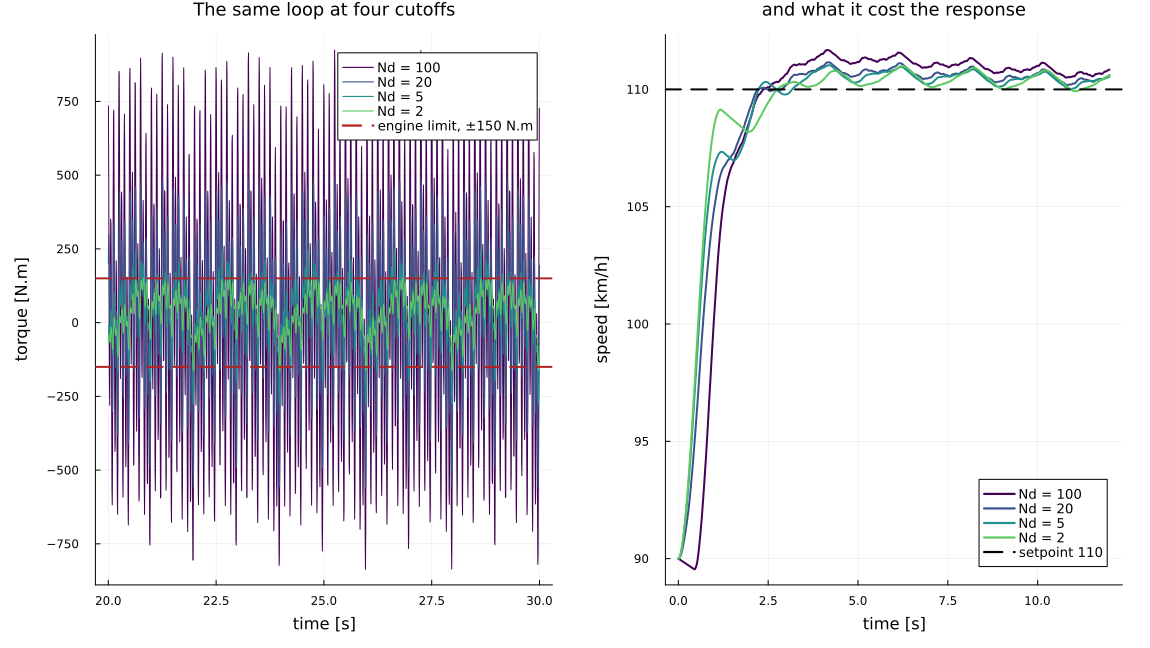

In [9]:
NDS = [100.0, 20.0, 5.0, 2.0]     # cutoffs Nd/Td: 200, 40, 10, 4 rad/s
ARRIVAL = (0.0, 12.0)             # the step and its settling, which is all a filter can cost

nd_family = sweep(near_pure, "Nd", NDS)

println("  Nd      cutoff [rad/s]   command range, 20-30 s [N.m]   overshoot on the step")
for (nd, sol) in nd_family
    u = last(segment(sol, COMMAND, CRUISE))
    println("  ", rpad(nd, 7), " ", rpad(round(nd / T_D, digits = 1), 16),
            " ", rpad(round(maximum(u) - minimum(u), digits = 2), 30),
            " ", round(overshoot(sol, SETPOINT; sig = TRUE_SPEED), digits = 2), " %")
end

# Drawn by hand rather than through `plot_sweep`, which plots a whole run: the two panels here
# read over different windows, and the chatter alone is tens of thousands of points per curve.
ramp = palette(:viridis, length(NDS) + 1)   # brightest shade dropped: unreadable on white

chatter = plot(; xlabel = "time [s]", ylabel = "torque [N.m]", legend = :topright,
               title = "The same loop at four cutoffs")
response = plot(; xlabel = "time [s]", ylabel = "speed [km/h]", legend = :bottomright,
                title = "and what it cost the response")
for (n, (nd, sol)) in enumerate(nd_family)
    tag = "Nd = $(Int(nd))"
    plot!(chatter, segment(sol, COMMAND, CRUISE)...; lw = 1, color = ramp[n], label = tag)
    plot!(response, segment(sol, TRUE_SPEED, ARRIVAL)...; lw = 2, color = ramp[n], label = tag)
end
hline!(chatter, [CAR.T_max, -CAR.T_max]; ls = :dash, lw = 2, color = :firebrick,
       label = "engine limit, ±150 N.m")
hline!(response, [SETPOINT]; ls = :dash, lw = 2, color = :black, label = "setpoint 110")

nd_plot = plot(chatter, response; layout = (1, 2), size = (1150, 650))
save_figure(nd_plot, "07-nd-family")
nd_plot

The chatter subsides, monotonically, and the step response on the right barely moves.

That is the good case for a filter and it is worth naming why it is the good case. The car's
closed loop does its work below about 1 rad/s — notebook 05's step takes the best part of a
second to cross 20 km/h. The noise starts at 0.5 Hz, which is 3.1 rad/s. The two live in
different places on the frequency axis, so there is room to put a cutoff between them: it takes
the noise away and leaves the car alone.

What it does not do is take the noise away entirely. At `Nd = 2` the command still swings over
300 N.m — twice the engine's limit — because the bottom of the noise band and the top of the
loop's own bandwidth are only a factor of three apart, and a first-order filter rolls off at six
decibels per octave. It cannot cut one without starting on the other.

## 5. Choosing the cutoff

Low enough to remove the noise. High enough to leave the signal. There is no third condition and
there is no formula, because the answer depends entirely on where your plant's dynamics sit and
where your sensor's noise sits — two facts about your hardware that no table can know.

What can be done is to measure both ends of the trade-off on this car. The sweep below runs the
same `Nd` values twice: once through the noisy speedometer, and once through a perfect one
(`amplitude = 0`). The perfect run has no noise to filter, so any overshoot it grows as `Nd`
falls is the filter eating the derivative's actual job.

In [10]:
TRADE = [20.0, 5.0, 2.0, 1.0, 0.5]

# `amplitude` is an ordinary parameter, so the noiseless loop is the same compiled model with
# the sum of sines turned off rather than a second model without the block in it.
clean = rerun(noisy, "amplitude" => 0.0)

noisy_trade = sweep(near_pure, "Nd", TRADE)
clean_trade = sweep(clean, "Nd", TRADE)

println("  Nd     cutoff [rad/s]   command range [N.m]   overshoot, noisy   overshoot, perfect sensor")
for ((nd, dirty), (_, spotless)) in zip(noisy_trade, clean_trade)
    u = last(segment(dirty, COMMAND, CRUISE))
    println("  ", rpad(nd, 6), " ", rpad(round(nd / T_D, digits = 1), 16),
            " ", rpad(round(maximum(u) - minimum(u), digits = 2), 21),
            " ", rpad(string(round(overshoot(dirty, SETPOINT; sig = TRUE_SPEED), digits = 2), " %"), 18),
            " ", round(overshoot(spotless, SETPOINT; sig = TRUE_SPEED), digits = 2), " %")
end

  Nd     cutoff [rad/s]   command range [N.m]   overshoot, noisy   overshoot, perfect sensor
  20.0   40.0             1039.43               5.79 %             3.07 %
  5.0    10.0             524.12                5.15 %             3.19 %
  2.0    4.0              315.29                4.98 %             3.15 %
  1.0    2.0              245.82                5.75 %             6.85 %
  0.5    1.0              193.48                15.95 %            16.98 %


Read the last two columns together and the trade-off is a shape with a bottom, exactly as
notebook 05's `Td` sweep was.

**From `Nd = 20` down to `Nd = 2` the filter is free.** The perfect-sensor column does not move —
the loop's own dynamics are all below 1 rad/s and a cutoff at 4 rad/s does not touch them — while
the command range falls by a factor of three. Every bit of that is noise removed at no cost.

**Below `Nd = 2` the filter starts charging.** At `Nd = 1` the cutoff is at 2 rad/s, close enough
to the loop's own bandwidth that the derivative is now looking at a lagged version of the car's
real motion, and the overshoot roughly doubles *on a sensor with no noise on it at all*. At
`Nd = 0.5` it has quintupled. The term is still there and it is still being multiplied by `Td`,
but what it is differentiating is no longer the present.

**And the best available answer is still not good enough for this car.** The command range
bottoms out somewhere around 300 N.m, twice the engine's limit, at an `Nd` where the response is
still intact. A first-order filter cannot do better here, because this speedometer's noise starts
at 0.5 Hz and the loop works at about 0.2 Hz — half a decade apart, which is not enough room.

When the two bands are that close, the honest conclusions are the ones that leave the filter
alone:

- **Use less derivative.** `Td` multiplies the whole path, noise included. Notebook 05's sweep
  showed `Td = 0.25` costs about seven points of overshoot; it also halves the derivative's
  share of every number in the command column above. Most industrial loops go further and run PI with no derivative at all,
  and this is the reason why.
- **Get a better measurement.** A speedometer whose noise starts at 20 Hz instead of 0.5 Hz makes
  this entire problem disappear, and is usually cheaper than the argument about it.
- **Stop filtering and start estimating.** A state estimator uses a model of the car to decide
  which parts of the measurement could possibly be the car moving, rather than deciding by
  frequency alone. That is a Kalman filter, and it is a different course.

Anyone who offers you a single number for `Nd` has assumed your plant. The library's default of
10 is a reasonable first guess and nothing more — on this car, with this sensor, it leaves a
command swinging over 700 N.m.

## 6. The same filter, built backwards

Worth knowing, because the block in your toolchain may well be implemented this way and it is
unreadable if you have not seen it before.

The filtered derivative

$$
\frac{s N}{s + N}
$$

is algebraically identical to a feedback loop with a gain of `N` in the forward path and an
integrator in the feedback path. Close that loop and the transfer function from input to output
is $N/(1 + N/s) = sN/(s+N)$ — the same thing, written with an integrator instead of a
differentiator.

The point of writing it that way is that there is no differentiator in it. A differentiator is
awkward to implement, numerically unforgiving and impossible to initialize sensibly; an
integrator is none of those. So the second form is cheaper and better behaved, and it is what
you will find inside a great many PID blocks — including, often, the ones drawn in textbooks as
a plain `s`.

It is also much harder to read, which is why it is worth recognizing rather than deriving.
`LimPID` uses the first form, and `Nd` is the `N` in it.

## What this bought us

The derivative's real cost, which is not a stability margin and not a tuning difficulty. It is
that differentiation multiplies by frequency, noise is mostly high frequency, and so a derivative
term is an amplifier pointed at the worst part of the signal. The size of the noise never
entered the argument.

Three things to carry out of this notebook.

- **A concrete reason `Nd` exists.** Every PID block in every toolchain has one. Most people
  never touch it, because most people never look at the actuator command — and on a clean
  simulation model, which is where most tuning is done, there is nothing there to see.
- **Filtering is a trade, not a fix.** It works when the signal and the noise sit in different
  places on the frequency axis, and only as well as they are separated. When they overlap, no
  choice of cutoff helps and the answer is a better sensor or a state estimator.
- **Plot the actuator command.** Twice in one lecture now, from two unrelated directions. The
  controlled variable looked fine through integral windup and it looks fine through this.

**Notebook 10** goes after the last assumption still standing. The engine has been the only
actuator in the lecture and its limit has been a number in newton-metres; the tire is an actuator
too, and its limit depends on the road. That notebook is not built — the wheel and slip models do
not exist yet. Until they do, **notebook 08** is where the lecture goes next: three tuning tables
that promise to find gains from a single step test, and what happens when you hold them against
the actuator this notebook has just spent ten pages looking at.